<a href="https://colab.research.google.com/github/ParamAhuja/DL_Notebooks/blob/main/elongated_bowl_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CASE 1: bad-scaled data

## original data

In [257]:
import pandas as pd
from sklearn.datasets import make_moons
import numpy as np

In [258]:
df = pd.read_csv('https://raw.githubusercontent.com/ParamAhuja/DL_Notebooks/refs/heads/main/datasets/Social_Network_Ads.csv')

In [259]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [260]:
df = df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [261]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

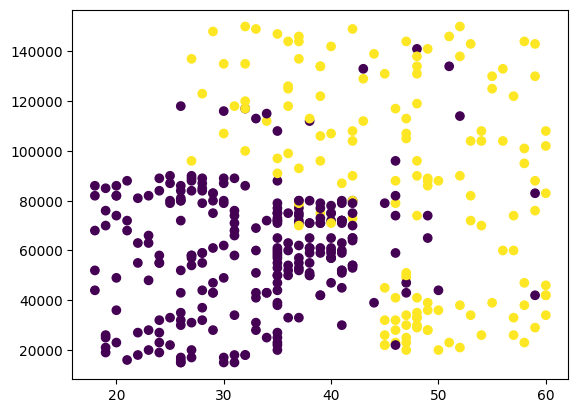

In [262]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [263]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def linear_model(X, weights, bias):
    return sigmoid(np.dot(X, weights) + bias)

In [264]:
def binary_cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-15  # To avoid division by zero
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Clip predictions to avoid log(0)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [265]:
# Create a meshgrid of weights and bias
# w1_min, w1_max = -5, 5
# w2_min, w2_max = -5, 5
# b_min, b_max = -5, 5
w1_min, w1_max = -0.5, 0.5
w2_min, w2_max = -0.5, 0.5
b_min, b_max = -0.5, 0.5

# For simplicity in visualization, let's fix the bias and vary only the two weights.
# If we wanted to visualize all three parameters (w1, w2, bias), we would need a 3D plot.
# Let's assume bias = 0 for this 2D contour plot of loss vs weights.
bias_fixed = 0

ww1, ww2 = np.meshgrid(np.arange(w1_min, w1_max, 0.1),
                       np.arange(w2_min, w2_max, 0.1))

In [266]:
# Calculate the loss for each point in the meshgrid
loss_values = np.zeros(ww1.shape)
for i in range(ww1.shape[0]):
    for j in range(ww1.shape[1]):
        weights = np.array([ww1[i, j], ww2[i, j]])
        predictions = linear_model(X, weights, bias_fixed)
        loss_values[i, j] = binary_cross_entropy_loss(y, predictions)

/tmp/ipython-input-263-3068593499.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


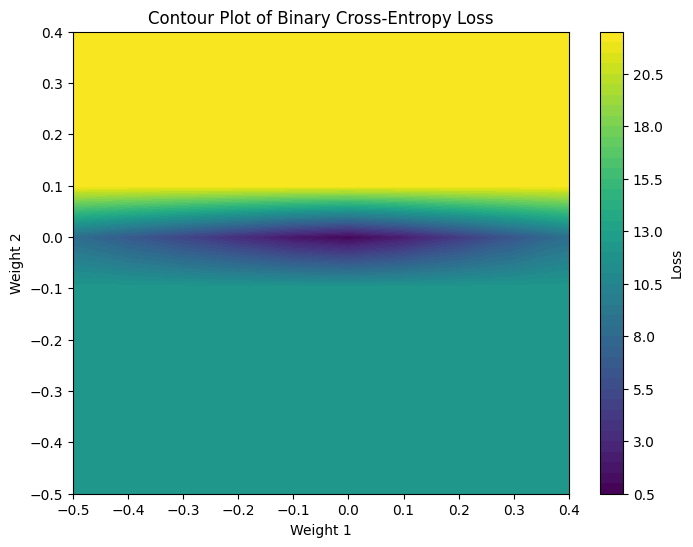

In [267]:
# Create the contour plot of the loss function
plt.figure(figsize=(8, 6))
contour = plt.contourf(ww1, ww2, loss_values, levels=50, cmap='viridis')
plt.colorbar(contour, label='Loss')
plt.title('Contour Plot of Binary Cross-Entropy Loss')
plt.xlabel('Weight 1')
plt.ylabel('Weight 2')
plt.show()

### result: elongated bowl shaped plot

## normalization

In [268]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [269]:
# Create a meshgrid of weights and bias
w1_min, w1_max = -5, 5
w2_min, w2_max = -5, 5
b_min, b_max = -5, 5

# For simplicity in visualization, let's fix the bias and vary only the two weights.
# If we wanted to visualize all three parameters (w1, w2, bias), we would need a 3D plot.
# Let's assume bias = 0 for this 2D contour plot of loss vs weights.
bias_fixed = 0

ww1, ww2 = np.meshgrid(np.arange(w1_min, w1_max, 0.1),
                       np.arange(w2_min, w2_max, 0.1))

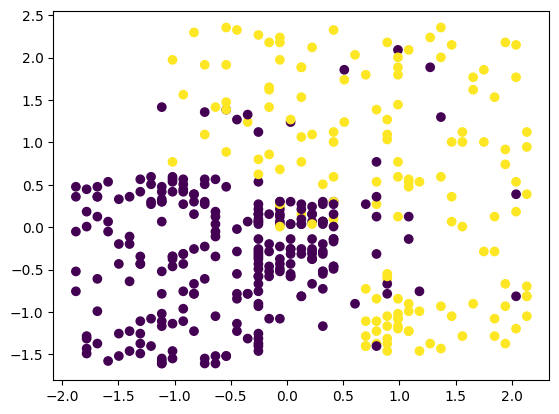

In [270]:
import matplotlib.pyplot as plt
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y)
plt.show()

In [271]:
# Calculate the loss for each point in the meshgrid
loss_values = np.zeros(ww1.shape)
for i in range(ww1.shape[0]):
    for j in range(ww1.shape[1]):
        weights = np.array([ww1[i, j], ww2[i, j]])
        predictions = linear_model(X_scaled, weights, bias_fixed)
        loss_values[i, j] = binary_cross_entropy_loss(y, predictions)

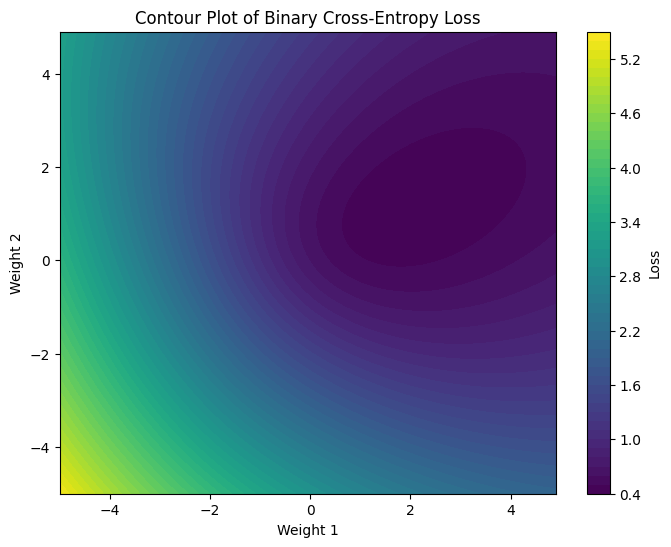

In [272]:
# Create the contour plot of the loss function
plt.figure(figsize=(8, 6))
contour = plt.contourf(ww1, ww2, loss_values, levels=50, cmap='viridis')
plt.colorbar(contour, label='Loss')
plt.title('Contour Plot of Binary Cross-Entropy Loss')
plt.xlabel('Weight 1')
plt.ylabel('Weight 2')
plt.show()

### result: much better

# CASE 2: SPARSE FEATURE

In [273]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-deep-learning/refs/heads/main/day3/placement.csv')

In [274]:
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


In [275]:
np.random.seed(42)

n_samples = df.shape[0]
sparsity_level = 0.80
n_sparse_values = int(n_samples * (1 - sparsity_level))

sparse_feature = np.zeros(n_samples)
non_zero_indices = np.random.choice(n_samples, n_sparse_values, replace=False)
sparse_feature[non_zero_indices] = 1

df['iit'] = sparse_feature
df.head()

,cgpa,resume_score,placed,iit
0,8.14,6.52,1,1.0
1,6.17,5.17,0,0.0
2,8.27,8.86,1,0.0
3,6.88,7.27,1,0.0
4,7.52,7.30,1,1.0


In [276]:
(df["iit"] == 1.0).sum()

np.int64(19)

In [277]:
X = df.drop(["placed", "cgpa"], axis =1)
y = df["placed"]

In [278]:
# Create a meshgrid of weights for 'resume_score' and 'iit', and the bias
# For a 2D contour plot, we need to fix one parameter and vary the other two.
# Let's fix the bias to 0 and vary the weights for 'resume_score' and 'iit'.
w_resume_min, w_resume_max = -10, 10  # Adjust range based on expected weight values
w_iit_min, w_iit_max = -10, 10      # Adjust range

bias_fixed = 0

ww_resume, ww_iit = np.meshgrid(np.arange(w_resume_min, w_resume_max, 0.1),
                               np.arange(w_iit_min, w_iit_max, 0.1))

In [279]:
# Calculate the loss for each point in the meshgrid
loss_values = np.zeros(ww_resume.shape)

for i in range(ww_resume.shape[0]):
    for j in range(ww_resume.shape[1]):
        # Create the weights array for the linear model [w_resume, w_iit]
        weights = np.array([ww_resume[i, j], ww_iit[i, j]])
        # Use the linear_model with X (containing 'resume_score' and 'iit') and fixed bias
        predictions = linear_model(X, weights, bias_fixed)
        # Calculate Binary Cross-Entropy loss
        loss_values[i, j] = binary_cross_entropy_loss(y, predictions)

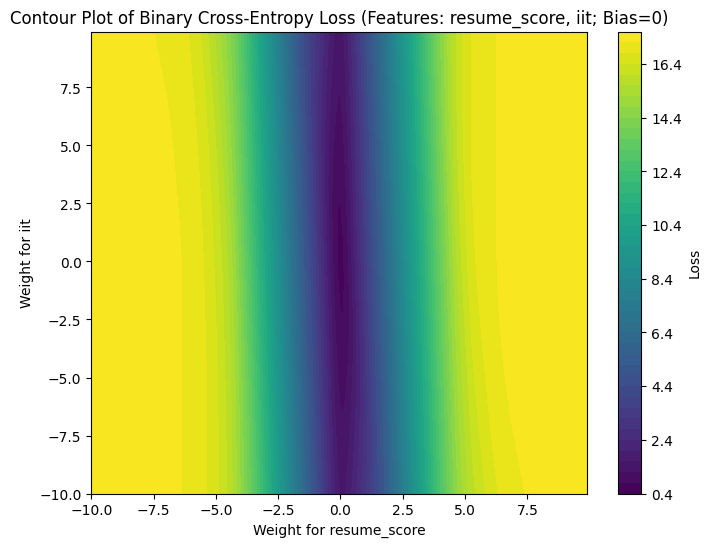

In [280]:
# Create the contour plot of the loss function
plt.figure(figsize=(8, 6))
contour = plt.contourf(ww_resume, ww_iit, loss_values, levels=50, cmap='viridis')
plt.colorbar(contour, label='Loss')
plt.title('Contour Plot of Binary Cross-Entropy Loss (Features: resume_score, iit; Bias=0)')
plt.xlabel('Weight for resume_score')
plt.ylabel('Weight for iit')
plt.show()

## result: obloooong plot

# CASE 3: One feature matters less than the other
i.e., cos x approximation using

 `P(x) = w0*b + w1* x**2 + w3* x**4`

In [281]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [282]:
# Prepare data with only x**2 and x**4 features
x_values = np.linspace(-5, 5, 50)
X_subset_features = np.array([x_values**2, x_values**4]).T
y_true = np.cos(x_values)

# Define the model function for contour plotting (varying w2 and w4, fixing bias w0)
def model_subset_features(X_subset, weights_subset, bias_fixed):
    # X_subset is (n_samples, 2) with [x**2, x**4]
    # weights_subset is (2,) with [w2, w4]
    # bias is scalar w0
    return X_subset @ weights_subset + bias_fixed

In [283]:
# Create a meshgrid of weights w2 and w4
w2_min, w2_max = -0.1, 0.1  # Adjusted range based on expected weight values for these features
w4_min, w4_max = -0.001, 0.001 # Adjusted range

# Fix bias (w0*b) to 0 for the contour plot
bias_fixed = 0

ww2, ww4 = np.meshgrid(np.arange(w2_min, w2_max, 0.001),
                       np.arange(w4_min, w4_max, 0.00001))

In [284]:
# Calculate the loss for each point in the meshgrid
loss_values = np.zeros(ww2.shape)
# Reshape y_true to match the shape of predictions (n_samples,)
y_true_reshaped = y_true.reshape(-1)

for i in range(ww2.shape[0]):
    for j in range(ww2.shape[1]):
        # Create the weights array for the model [w2, w4]
        weights_subset = np.array([ww2[i, j], ww4[i, j]])
        # Use the model_subset_features with the subset of X and fixed bias
        predictions = model_subset_features(X_subset_features, weights_subset, bias_fixed)
        # Calculate MSE loss
        loss_values[i, j] = mean_squared_error(y_true_reshaped, predictions)

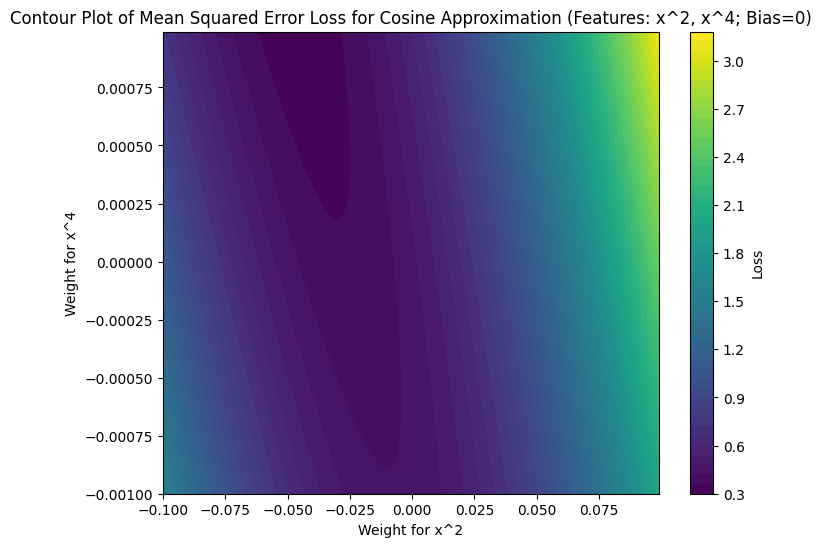

In [285]:
# Create the contour plot of the loss function
plt.figure(figsize=(8, 6))
contour = plt.contourf(ww2, ww4, loss_values, levels=50, cmap='viridis')
plt.colorbar(contour, label='Loss')
plt.title('Contour Plot of Mean Squared Error Loss for Cosine Approximation (Features: x^2, x^4; Bias=0)')
plt.xlabel('Weight for x^2')
plt.ylabel('Weight for x^4')
plt.show()

## result: oblong plot because w4 matters much less than w2 (much less sensitive)